In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [46]:
# Load the Excel file
data = pd.read_excel('data/airqualityuci.xlsx')

data.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


CO(GT) : True measured concentration of carbon monoxide in the air (mg/m³).

PT08.S1(CO) : Sensor 1 output, primarily sensitive to CO and other reducing gases.

NMHC(GT) : True measured concentration of non-methane hydrocarbons (µg/m³).

C6H6(GT) : True measured concentration of benzene (µg/m³).

PT08.S2(NMHC) : Sensor 2 output, mainly responsive to hydrocarbons (NMHC).

NOx(GT) : True measured concentration of nitrogen oxides (ppb).

PT08.S3(NOx) : Sensor 3 output, sensitive to nitric oxide and related compounds.

NO2(GT) : True measured concentration of nitrogen dioxide (µg/m³).

PT08.S4(NO2) : Sensor 4 output, primarily sensitive to NO₂.

PT08.S5(O3) : Sensor 5 output, mainly sensitive to ozone and secondary oxidizing agents.

T : Ambient air temperature (°C).

RH : Relative humidity (%).

AH : Absolute humidity (g/m³).

| Type                                     | Columns                                                                       | Description                                            |
| ---------------------------------------- | ----------------------------------------------------------------------------- | -------------------------------------------------- |
| **Ground truth pollutants (GT)**         | `CO(GT)`, `NO2(GT)`, `NOx(GT)`, `C6H6(GT)`                                    | Reference lab-grade measurements (accurate)        |
| **Electrochemical sensor outputs (raw)** | `PT08.S1(CO)`, `PT08.S2(NMHC)`, `PT08.S3(NOx)`, `PT08.S4(NO2)`, `PT08.S5(O3)` | Raw resistance-based responses from each sensor          |
| **Environmental conditions**             | `T`, `RH`, `AH`                                                               | Ambient temperature & humidity that affect sensors |


In [47]:
data.shape          # rows and columns
data.info()         # data types, null counts
data.describe()     # summary stats

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           9357 non-null   datetime64[ns]
 1   Time           9357 non-null   object        
 2   CO(GT)         9357 non-null   float64       
 3   PT08.S1(CO)    9357 non-null   float64       
 4   NMHC(GT)       9357 non-null   int64         
 5   C6H6(GT)       9357 non-null   float64       
 6   PT08.S2(NMHC)  9357 non-null   float64       
 7   NOx(GT)        9357 non-null   float64       
 8   PT08.S3(NOx)   9357 non-null   float64       
 9   NO2(GT)        9357 non-null   float64       
 10  PT08.S4(NO2)   9357 non-null   float64       
 11  PT08.S5(O3)    9357 non-null   float64       
 12  T              9357 non-null   float64       
 13  RH             9357 non-null   float64       
 14  AH             9357 non-null   float64       
dtypes: datetime64[ns](1),

,Date,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,2004-09-21 04:30:05.193972480,-34.207524,1048.869652,-159.090093,1.865576,894.475963,168.604200,794.872333,58.135898,1391.363266,974.951534,9.776600,39.483611,-6.837604
min,2004-03-10 00:00:00,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,2004-06-16 00:00:00,0.600000,921.000000,-200.000000,4.004958,711.000000,50.000000,637.000000,53.000000,1184.750000,699.750000,10.950000,34.050000,0.692275
50%,2004-09-21 00:00:00,1.500000,1052.500000,-200.000000,7.886653,894.500000,141.000000,794.250000,96.000000,1445.500000,942.000000,17.200000,48.550000,0.976823
75%,2004-12-28 00:00:00,2.600000,1221.250000,-200.000000,13.636091,1104.750000,284.200000,960.250000,133.000000,1662.000000,1255.250000,24.075000,61.875000,1.296223
max,2005-04-04 00:00:00,11.900000,2039.750000,1189.000000,63.741476,2214.000000,1479.000000,2682.750000,339.700000,2775.000000,2522.750000,44.600000,88.725000,2.231036
std,NaN,77.657170,329.817015,139.789093,41.380154,342.315902,257.424561,321.977031,126.931428,467.192382,456.922728,43.203438,51.215645,38.976670


In [48]:
data.isnull().sum()

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

In [49]:
data.duplicated().sum()

np.int64(0)

In [ ]:
# won't do time series analysis here
data.drop(columns=['Date', 'Time'], inplace=True)

In [51]:
data.replace(-200, np.nan, inplace=True)

In [52]:
missing = data.isna().mean().sort_values(ascending=False) * 100
print(missing)

NMHC(GT)         90.231912
CO(GT)           17.986534
NO2(GT)          17.548360
NOx(GT)          17.516298
PT08.S1(CO)       3.911510
PT08.S2(NMHC)     3.911510
C6H6(GT)          3.911510
PT08.S3(NOx)      3.911510
PT08.S4(NO2)      3.911510
PT08.S5(O3)       3.911510
T                 3.911510
RH                3.911510
AH                3.911510
dtype: float64


In [53]:
# dropping 'NMHC(GT)' column due to high missing values
data.drop(columns=['NMHC(GT)'], inplace=True)

In [54]:
# Interpolating missing values linearly
data = data.interpolate(method='linear', limit_direction='forward')

In [55]:
data.describe()     # summary stats

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,2.130603,1102.932925,10.178838,942.019562,241.908464,832.634930,109.620033,1453.172887,1032.422456,18.231754,49.189157,1.019621
std,1.431736,218.201561,7.503295,267.864854,204.308147,255.708807,46.451523,343.201361,404.442611,8.782368,17.194081,0.402203
min,0.100000,647.250000,0.149048,383.250000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.175000,0.184679
25%,1.100000,937.500000,4.477145,736.000000,96.000000,654.000000,76.000000,1227.000000,733.250000,11.725000,35.800000,0.732280
50%,1.800000,1066.750000,8.289085,910.333333,180.000000,803.500000,104.827586,1459.500000,970.000000,17.575000,49.650000,0.989504
75%,2.900000,1238.750000,14.096486,1119.000000,326.000000,967.500000,136.400000,1668.250000,1293.000000,24.275001,62.250002,1.306671
max,11.900000,2039.750000,63.741476,2214.000000,1479.000000,2682.750000,339.700000,2775.000000,2522.750000,44.600000,88.725000,2.231036


In [56]:
skewness = data.skew(numeric_only=True)
print(skewness.sort_values(ascending=False))

NOx(GT)          1.697949
C6H6(GT)         1.337111
CO(GT)           1.292296
PT08.S3(NOx)     1.091018
PT08.S1(CO)      0.711457
NO2(GT)          0.707153
PT08.S5(O3)      0.602994
PT08.S2(NMHC)    0.557177
T                0.325244
AH               0.259391
PT08.S4(NO2)     0.207832
RH              -0.043945
dtype: float64


In [57]:
missing = data.isna().mean().sort_values(ascending=False) * 100
print(missing)

CO(GT)           0.0
PT08.S1(CO)      0.0
C6H6(GT)         0.0
PT08.S2(NMHC)    0.0
NOx(GT)          0.0
PT08.S3(NOx)     0.0
NO2(GT)          0.0
PT08.S4(NO2)     0.0
PT08.S5(O3)      0.0
T                0.0
RH               0.0
AH               0.0
dtype: float64


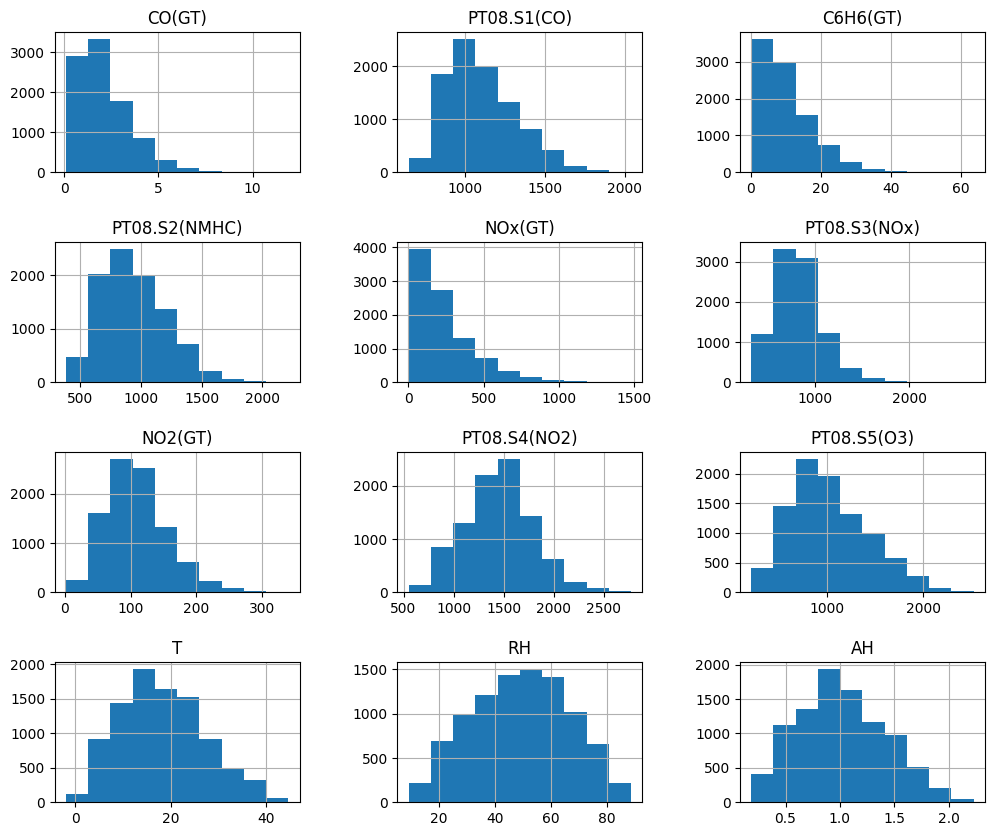

In [58]:
data.hist(figsize=(12, 10))
plt.subplots_adjust(hspace=0.5, wspace=0.4)
plt.show()

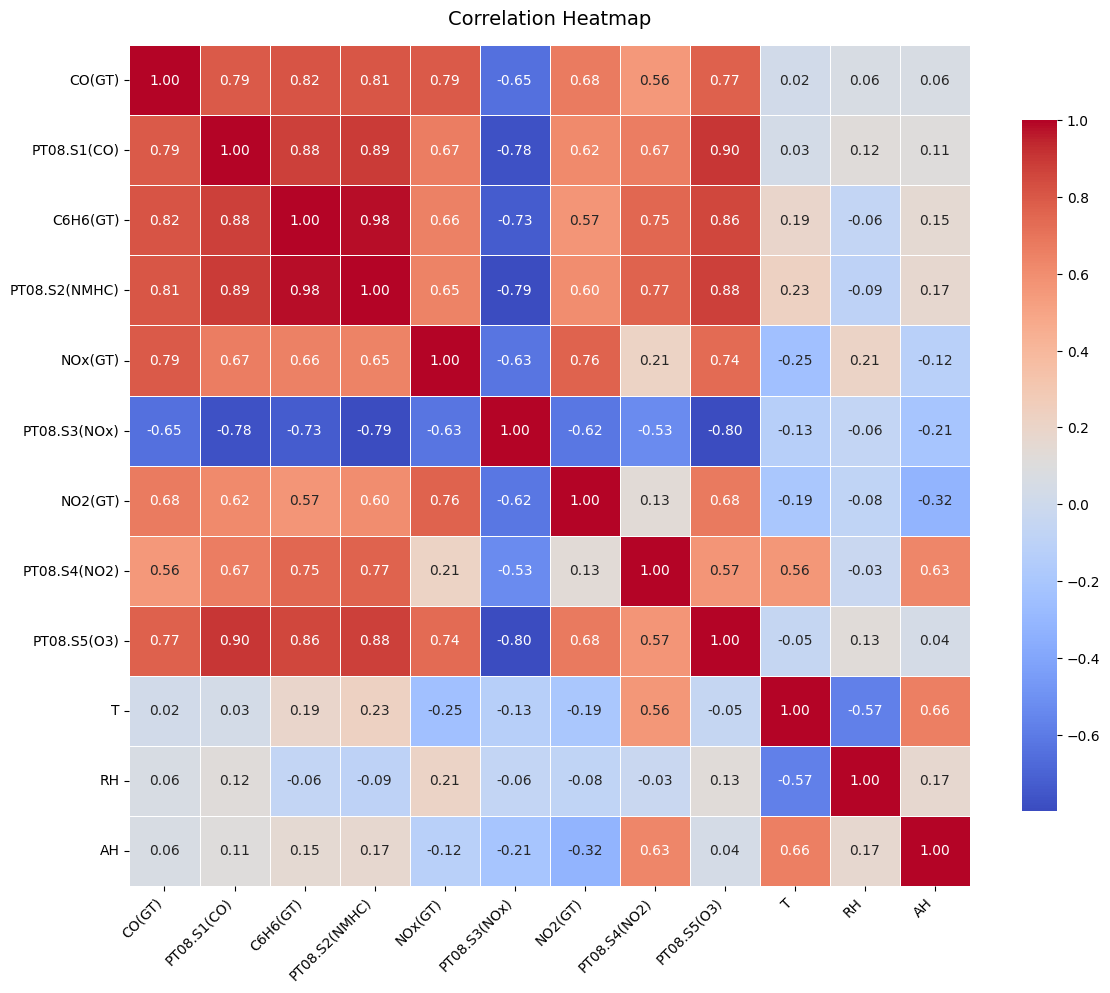

In [59]:
numeric_df = data.select_dtypes(include=['float64', 'int64'])

corr = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    square=True
)
plt.title("Correlation Heatmap", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [60]:
print(data.columns)

Index(['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)',
       'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH',
       'AH'],
      dtype='object')


In [61]:
# Split into features (X) and target (y)
X = data[['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']]

y = data['NO2(GT)']

In [62]:
data.head()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.00,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2.0,1292.25,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2.2,1402.00,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2.2,1375.50,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,1.6,1272.25,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


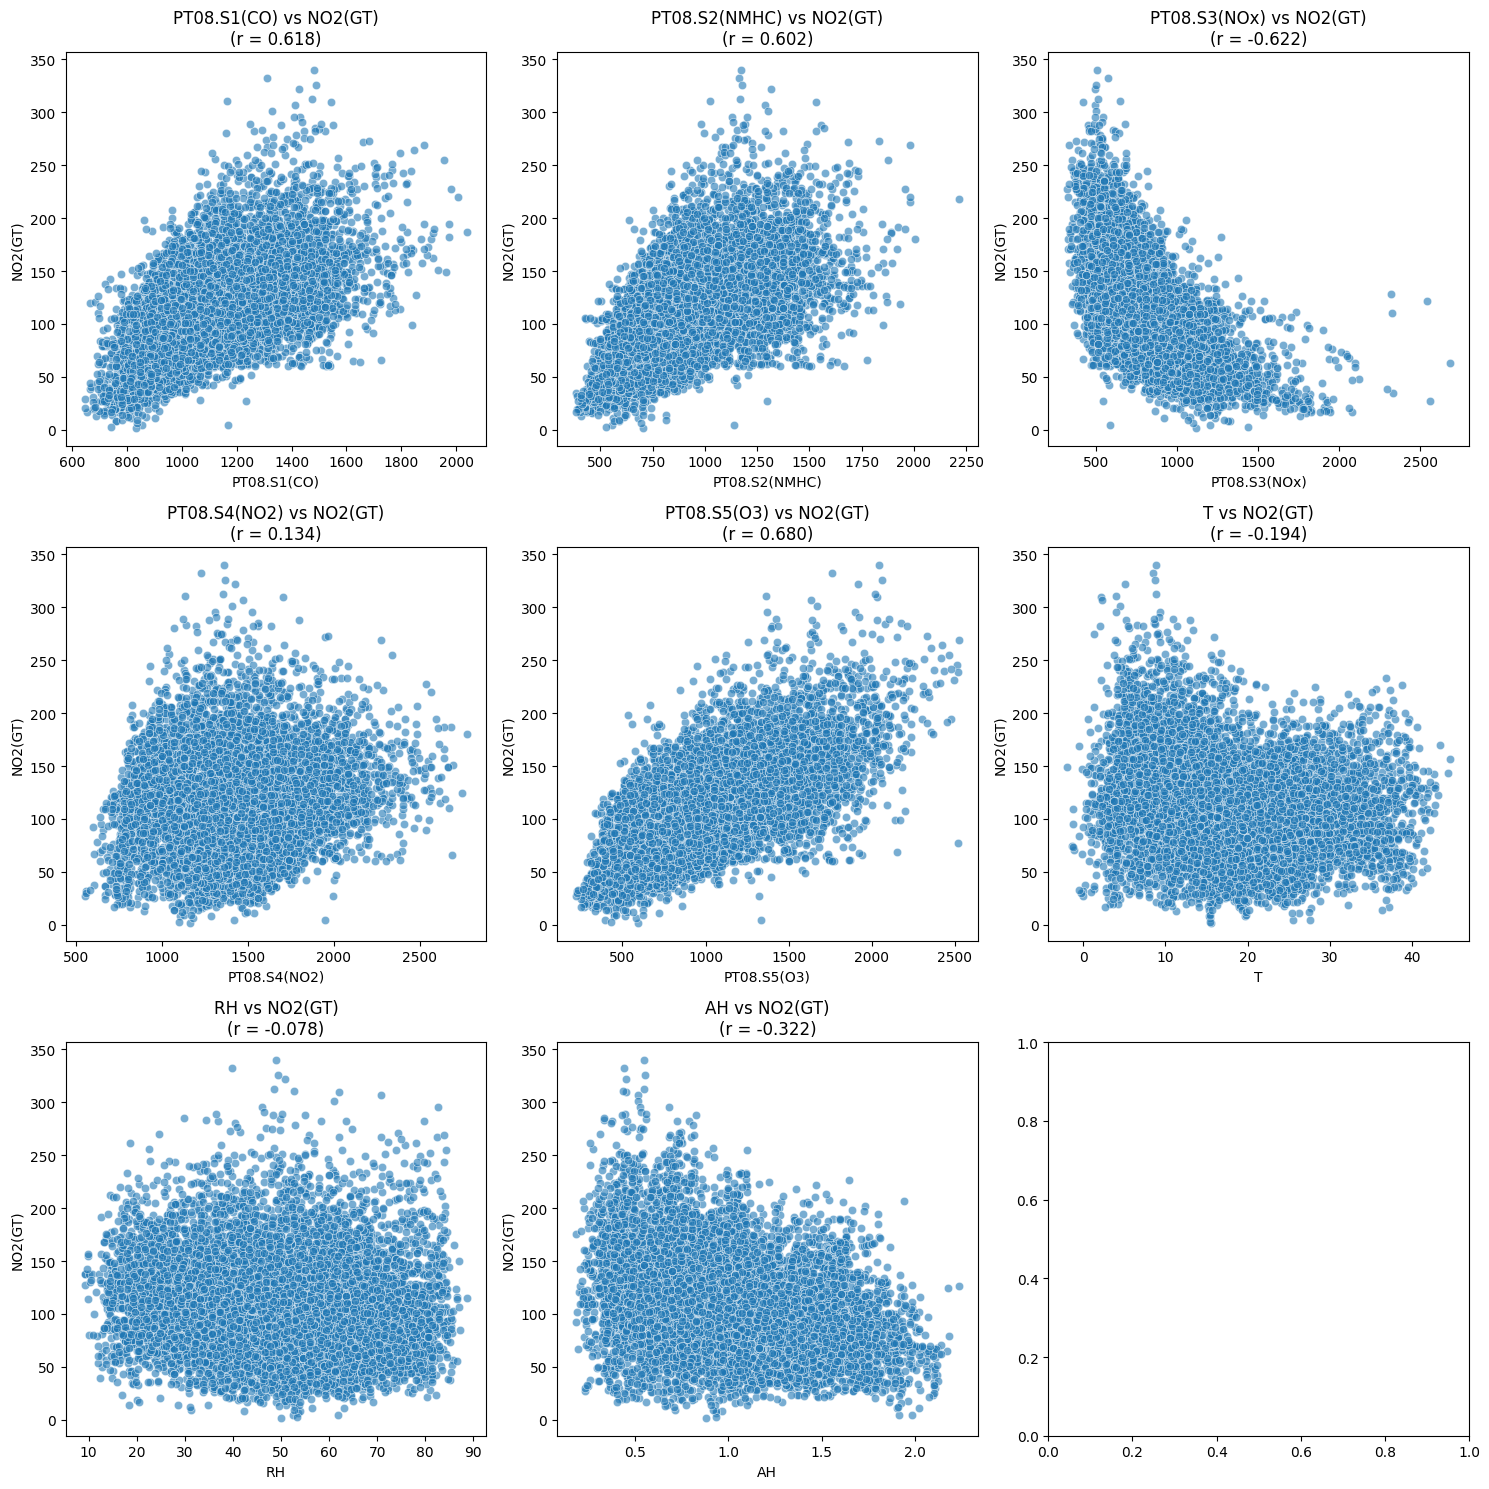

In [63]:
# Calculate grid dimensions
n_features = len(X.columns)
n_cols = 3  # Number of columns in the grid
n_rows = (n_features + n_cols - 1) // n_cols  # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for i, col in enumerate(X.columns):
    sns.scatterplot(x=X[col], y=y, alpha=0.6, ax=axes[i])
    corr_value = X[col].corr(y)
    axes[i].set_title(f"{col} vs {y.name}\n(r = {corr_value:.3f})")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(y.name)

plt.tight_layout()
plt.show()

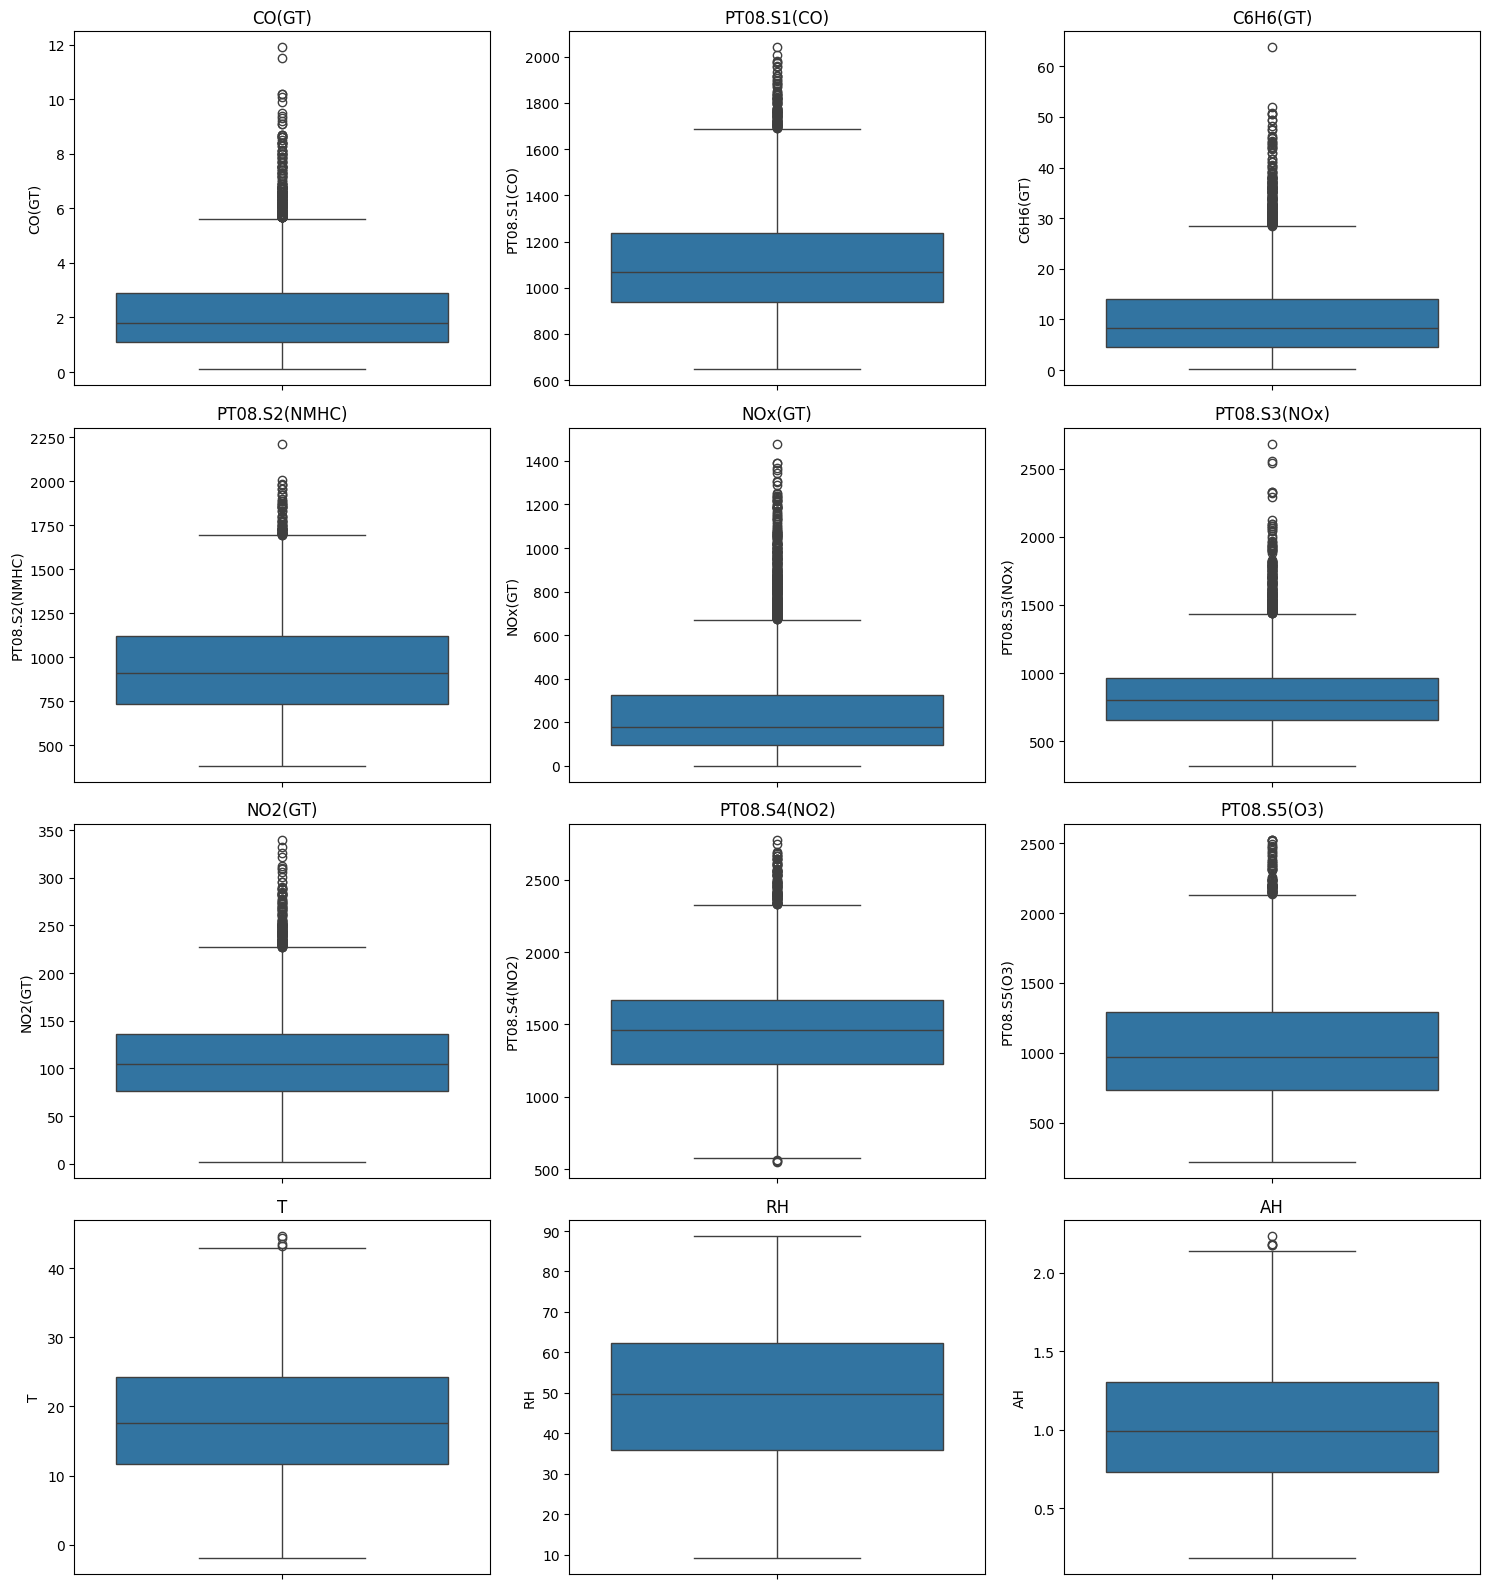

In [64]:
# Calculate grid dimensions for box plots
n_features = len(numeric_df.columns)
n_cols = 3  # Number of columns in the grid
n_rows = (n_features + n_cols - 1) // n_cols  # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for i, col in enumerate(numeric_df.columns):
    sns.boxplot(y=numeric_df[col], ax=axes[i])
    axes[i].set_title(f"{col}")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [65]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
PT08.S1(CO),9357.0,1102.932925,218.201561,647.250000,937.50000,1066.750000,1238.750000,2039.750000
PT08.S2(NMHC),9357.0,942.019562,267.864854,383.250000,736.00000,910.333333,1119.000000,2214.000000
PT08.S3(NOx),9357.0,832.634930,255.708807,322.000000,654.00000,803.500000,967.500000,2682.750000
PT08.S4(NO2),9357.0,1453.172887,343.201361,551.000000,1227.00000,1459.500000,1668.250000,2775.000000
PT08.S5(O3),9357.0,1032.422456,404.442611,221.000000,733.25000,970.000000,1293.000000,2522.750000
T,9357.0,18.231754,8.782368,-1.900000,11.72500,17.575000,24.275001,44.600000
RH,9357.0,49.189157,17.194081,9.175000,35.80000,49.650000,62.250002,88.725000
AH,9357.0,1.019621,0.402203,0.184679,0.73228,0.989504,1.306671,2.231036


In [66]:
y.describe().T

count    9357.000000
mean      109.620033
std        46.451523
min         2.000000
25%        76.000000
50%       104.827586
75%       136.400000
max       339.700000
Name: NO2(GT), dtype: float64

In [67]:
X.head()

,PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,1360.00,1045.50,1056.25,1692.00,1267.50,13.60,48.875001,0.757754
1,1292.25,954.75,1173.75,1558.75,972.25,13.30,47.700000,0.725487
2,1402.00,939.25,1140.00,1554.50,1074.00,11.90,53.975000,0.750239
3,1375.50,948.25,1092.00,1583.75,1203.25,11.00,60.000000,0.786713
4,1272.25,835.50,1205.00,1490.00,1110.00,11.15,59.575001,0.788794


In [68]:
X.count()

PT08.S1(CO)      9357
PT08.S2(NMHC)    9357
PT08.S3(NOx)     9357
PT08.S4(NO2)     9357
PT08.S5(O3)      9357
T                9357
RH               9357
AH               9357
dtype: int64

In [69]:
# Combine X and y back into a single DataFrame for saving
data = pd.concat([X, y], axis=1)

# Save cleaned data to a new CSV file
data.to_csv("data/clean_air_quality.csv", index=False)